In [39]:
# basic modules for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [27]:
df = pd.read_csv('mentions_english.csv')

In [28]:
df.head()

,actor,date,external_actors,text_en
0,AA,03/01/2022 14:01,Bangladesh,Interview with the Arakan Army Commander-in-Ch...
1,AA,26/03/2022 20:38,Bangladesh,Congratulatory Statement to the Independence D...
2,AA,02/07/2022 21:58,West,Explanation about the recently released videos...
3,AA,04/07/2022 22:25,Thailand,A military council airstrike on a Rakhine Army...
4,AA,05/07/2022 13:29,Thailand,"On July 4, 2022, at 12:25 p.m., a military cou..."


#### Cleaning and Data Overview

In [29]:
df.describe()

,actor,date,external_actors,text_en
count,7365,7365,7365,7365
unique,9,7015,158,7190
top,SAC (SSPC) 1,06/05/2023 20:40,Thailand,Photo: Bangkok Post
freq,2625,8,1418,14


In [30]:
df["actor"].unique()

array(['AA', 'CNF', 'SAC (SSPC) 1', 'SAC (SSPC) 2', 'KNU', 'KNDF',
       'SAC (SSPC) 3', 'NUG', 'PSLF/TNLA'], dtype=object)

In [31]:
# let's replace different variants of SAC with a single label "SAC"

SAC_VARIANTS = [
    "SAC (SSPC) 1",
    "SAC (SSPC) 2",
    "SAC (SSPC) 3",
]

df["actor"] = df["actor"].replace(SAC_VARIANTS, "SAC")

In [32]:
df["external_actors"].unique()

array(['Bangladesh', 'West', 'Thailand', 'India', 'China', 'Humanitarian',
       'ASEAN, Humanitarian, West', 'Bangladesh, India',
       'Bangladesh, West', 'UN', 'China, West', 'Bangladesh, Thailand',
       'Thailand, West', 'Bangladesh, China, Russia, Thailand, West',
       'ASEAN, UN', 'ASEAN', 'China, Russia, UN, West', 'India, UN, West',
       'UN, West', 'ASEAN, China, Russia, West', 'Russia, West',
       'China, Russia', 'Russia', 'China, Russia, West', 'India, Russia',
       'Russia, UN, West', 'Russia, UN', 'ASEAN, India',
       'Humanitarian, Thailand, UN, West',
       'ASEAN, China, India, Russia, West', 'ASEAN, West',
       'China, Russia, Thailand, West', 'China, Humanitarian, West',
       'China, India, Russia, West', 'ASEAN, Thailand',
       'ASEAN, China, Russia, UN, West',
       'China, Russia, Thailand, UN, West', 'China, UN, West',
       'ASEAN, China, Thailand, West', 'China, India, Russia, Thailand',
       'China, Thailand', 'India, West', 'China, Th

In [33]:
# let's leave only one external actor for each post

df_mentions = (
    df.assign(
        external_actor=df["external_actors"]
            .fillna("")
            .str.split(",")
    )
    .explode("external_actor")
    .assign(
        external_actor=lambda x: x["external_actor"].str.strip()
    )
    .query('external_actor != ""')
)

In [34]:
df_mentions.describe()

,actor,date,external_actors,text_en,external_actor
count,9540,9540,9540,9540,9540
unique,7,7015,158,7190,9
top,SAC,14/11/2024 18:26,Thailand,Photo: Bangkok Post,West
freq,7021,15,1418,14,2055


In [35]:
df_mentions = df_mentions.drop(columns=["external_actors"])

In [36]:
df_mentions.describe()

,actor,date,text_en,external_actor
count,9540,9540,9540,9540
unique,7,7015,7190,9
top,SAC,14/11/2024 18:26,Photo: Bangkok Post,West
freq,7021,15,14,2055


#### Who mentions whom

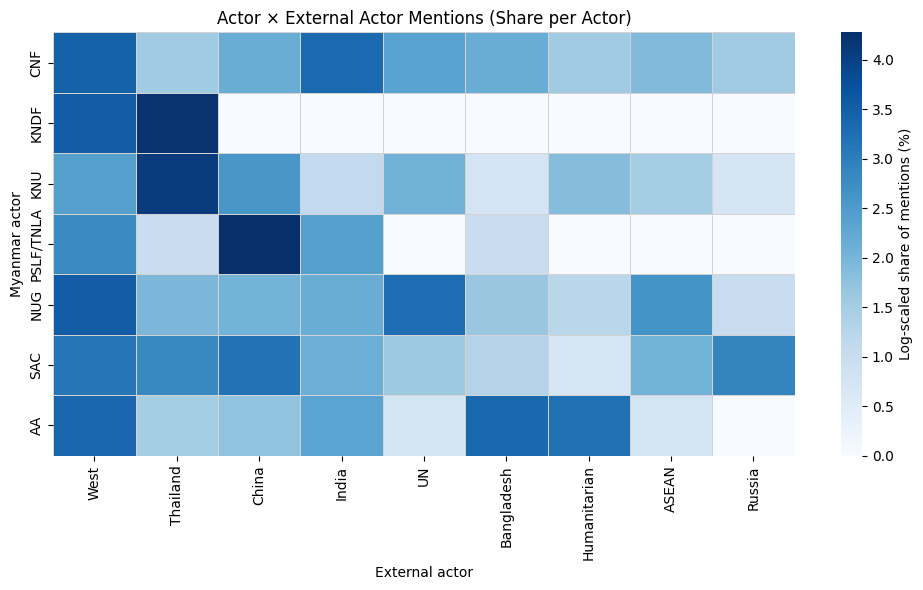

In [46]:
# let's build a heatmap of mentions shares

counts = (
    df_mentions
    .groupby(["actor", "external_actor"])
    .size()
    .reset_index(name="n_mentions")
)

counts["share"] = (
    counts["n_mentions"]
    / counts.groupby("actor")["n_mentions"].transform("sum")
)

matrix = (
    counts
    .pivot(index="actor", columns="external_actor", values="share")
    .fillna(0)
)

matrix = matrix.loc[
    matrix.sum(axis=1).sort_values(ascending=False).index,
    matrix.sum(axis=0).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    np.log1p(matrix * 100),
    cmap="Blues",
    linewidths=0.5,
    linecolor="lightgrey",
    cbar_kws={"label": "Log-scaled share of mentions (%)"},
)

plt.title("Actor × External Actor Mentions (Share per Actor)")
plt.xlabel("External actor")
plt.ylabel("Myanmar actor")

plt.tight_layout()
plt.show()

#### Temporal dynamics

#### Narrative depth

#### Semantic structure

#### Sentiment / stance

#### Network view

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("./miniLM-v2")

df['text_en'] = df['text_en'].fillna('')

texts = df['text_en'].tolist()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

df['vector'] = list(embeddings)

c:\Users\ukhal\anaconda3\envs\datascience\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batches: 100%|██████████| 231/231 [00:15<00:00, 14.49it/s]


c:\Users\ukhal\anaconda3\envs\datascience\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ukhal\anaconda3\envs\datascience\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


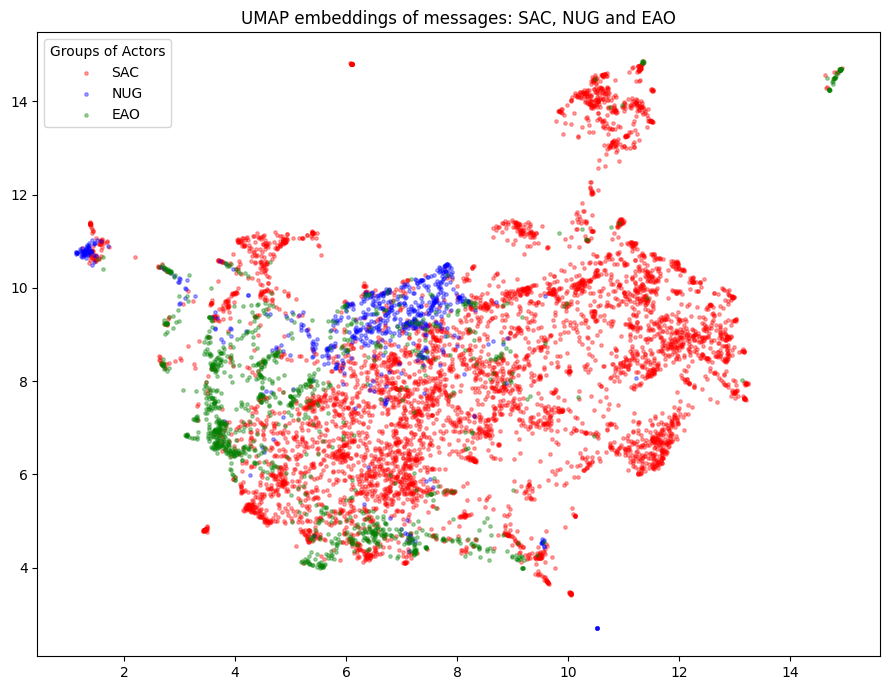

In [9]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

coords_2d = reducer.fit_transform(embeddings)
df['x'] = coords_2d[:, 0]
df['y'] = coords_2d[:, 1]

def categorize_actor(a):
    if "SAC" in a or "SSPC" in a:
        return "SAC"
    elif a == "NUG":
        return "NUG"
    else:
        return "EAO"
    
df['group'] = df['actor'].apply(categorize_actor)

colors = {
    "SAC": "red",
    "NUG": "blue",
    "EAO": "green"
}

plt.figure(figsize=(9, 7))

for group in ["SAC", "NUG", "EAO"]:
    sub = df[df['group'] == group]
    plt.scatter(
        sub['x'], sub['y'],
        s=6,
        alpha=0.35,
        color=colors[group],
        label=group
    )

plt.legend(title="Groups of Actors")
plt.title("UMAP embeddings of messages: SAC, NUG and EAO")
plt.tight_layout()
plt.show()